In [2]:
!pip install -q torch torchvision matplotlib

In [3]:
import torch

import torch.nn as nn

import matplotlib.pyplot as plt

import numpy as np

In [4]:
labels = {

    0: "normal",

    1: "pneumonia"
}

print(labels)

{0: 'normal', 1: 'pneumonia'}


In [5]:
class SelfAttention(nn.Module):

    def __init__(self, in_dim):

        super(SelfAttention, self).__init__()

        self.query = nn.Linear(
            in_dim,
            in_dim
        )

        self.key = nn.Linear(
            in_dim,
            in_dim
        )

        self.value = nn.Linear(
            in_dim,
            in_dim
        )

    def forward(self, x):

        Q = self.query(x)

        K = self.key(x)

        V = self.value(x)

        attention = torch.softmax(

            torch.matmul(
                Q,
                K.T
            ),

            dim=-1
        )

        out = torch.matmul(
            attention,
            V
        )

        return out

In [6]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        # Text Embedding
        self.embedding = nn.Embedding(
            2,
            10
        )

        # Attention Layer
        self.attention = SelfAttention(10)

        # Generator Network
        self.fc = nn.Sequential(

            nn.Linear(20,128),

            nn.ReLU(),

            nn.Linear(128,784),

            nn.Tanh()
        )

    def forward(self, noise, labels):

        # Convert labels into embeddings
        text_embed = self.embedding(labels)

        # Apply attention
        attended_text = self.attention(
            text_embed
        )

        # Combine noise + text
        x = torch.cat(
            [noise, attended_text],
            dim=1
        )

        # Generate image
        img = self.fc(x)

        img = img.view(-1,28,28)

        return img


In [7]:
generator = Generator()

print(generator)

Generator(
  (embedding): Embedding(2, 10)
  (attention): SelfAttention(
    (query): Linear(in_features=10, out_features=10, bias=True)
    (key): Linear(in_features=10, out_features=10, bias=True)
    (value): Linear(in_features=10, out_features=10, bias=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Tanh()
  )
)


In [8]:
label = torch.tensor([1])

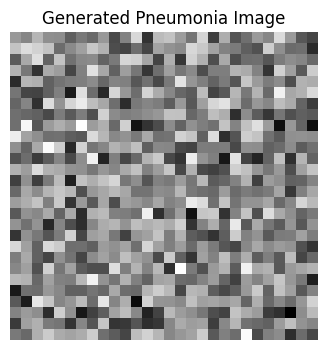

In [9]:
noise = torch.randn(1,10)

# 0 = normal
# 1 = pneumonia

label = torch.tensor([1])

generated = generator(
    noise,
    label
).detach().numpy()[0]

plt.figure(figsize=(4,4))

plt.imshow(
    generated,
    cmap="gray"
)

plt.title(
    "Generated Pneumonia Image"
)

plt.axis("off")

plt.show()

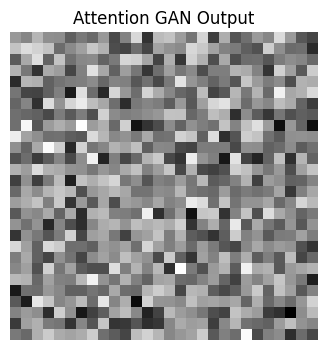

In [10]:
plt.figure(figsize=(4,4))

plt.imshow(
    generated,
    cmap="gray"
)

plt.title(
    "Attention GAN Output"
)

plt.axis("off")

plt.savefig("task5_output.png")

plt.show()